### Import from drive

In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

### Import required libraries

In [11]:
!pip install metric-learn

In [12]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126


In [13]:
import os, sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Detect Colab
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Assumes drive is already mounted in a previous cell
    PROJECT_ROOT = Path("/content/drive/MyDrive/NN-kNN")
    DATA_ROOT    = Path("/content/datasets")
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running on Colab.")
else:
    PROJECT_ROOT = Path(os.getcwd())          # notebook's current folder as project root
    DATA_ROOT    = PROJECT_ROOT / "datasets"
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running locally.")

# Make project importable and set CWD to project root for consistent relative paths
# Add PROJECT_ROOT to sys.path *before* importing from within the project
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)


from model.nnknn_model import NN_KNN_Model, train_model, default_args, GlocalFeatureWeight
from model.mlkr import run_mlkr_sklearn
from datasets.reg_data import Reg_data, standardize_tensor

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT     =", DATA_ROOT)
print("CHECKPOINTS  =", CHECKPOINTS)

# Optional: pick device
try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception as e:
    print("Torch not available (only matters if you need it):", e)

Running locally.
PROJECT_ROOT = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN
DATA_ROOT     = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\datasets
CHECKPOINTS  = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\checkpoints
Using device: cuda


In [14]:
!pip install gymnasium

In [15]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import random
from collections import deque, namedtuple
import torch.nn as nn

# DQN + NN-kNN for the MountainCar family

This notebook is specialized for the MountainCar environments in Gymnasium:

- `MountainCar-v0` (discrete actions)
- `MountainCarContinuous-v0` (continuous throttle)

For the continuous environment, the notebook uses a **discretized action grid** so that:
- the DQN still predicts over a finite set of action bins
- the NN-kNN still scores state-action cases consistently
- video recording / evaluation / explanations all work with the same action-index helpers

### Simple DQN

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

import os, random, torch
import gymnasium as gym
import torch.nn as nn
import torch.optim as optim
from collections import deque
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### DQN baseline for MountainCar / MountainCarContinuous

This DQN section is written for the MountainCar family only.

- In `MountainCar-v0`, actions are the environment's native discrete actions.
- In `MountainCarContinuous-v0`, the continuous action is approximated with a small set of throttle bins.

In [18]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Replay Buffer for DQN experience
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

# Epsilon-greedy policy
def select_action(state, policy_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = policy_net(state_t)
        return q_values.argmax(dim=1).item()

In [19]:
gym.pprint_registry()


===== classic_control =====
Acrobot-v1             CartPole-v0            CartPole-v1
MountainCar-v0         MountainCarContinuous-v0 Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0     phys2d/CartPole-v1     phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3       BipedalWalkerHardcore-v3 CarRacing-v3
LunarLander-v3         LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1           CliffWalking-v1        CliffWalkingSlippery-v1
FrozenLake-v1          FrozenLake8x8-v1       Taxi-v3
===== tabular =====
tabular/Blackjack-v0   tabular/CliffWalking-v0
===== None =====
Ant-v2                 Ant-v3                 GymV21Environment-v0
GymV26Environment-v0   HalfCheetah-v2         HalfCheetah-v3
Hopper-v2              Hopper-v3              Humanoid-v2
Humanoid-v3            HumanoidStandup-v2     InvertedDoublePendulum-v2
InvertedPendulum-v2    Pusher-v2              Reacher-v2
Swimmer-v2             Swimmer-v3             Walker2d-v2
Walker2d-v3
===== mujoco =====
Ant-v4    

In [20]:
# --- Hyperparameters ---
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
TARGET_UPDATE = 500
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 0.992
MAX_EPISODES = 500
MAX_STEPS = 999

# --- MountainCar family switch ---
# "discrete"   -> MountainCar-v0
# "continuous" -> MountainCarContinuous-v0
ENV_VARIANT = "discrete"

# Used only for MountainCarContinuous-v0
# Feel free to make this denser, e.g. np.linspace(-1.0, 1.0, 9)
CONTINUOUS_ACTION_BINS = np.array([-1.0, -0.5, 0.0, 0.5, 1.0], dtype=np.float32)

if ENV_VARIANT not in {"discrete", "continuous"}:
    raise ValueError(f"Unsupported ENV_VARIANT={ENV_VARIANT!r}")

ENV_ID = "MountainCar-v0" if ENV_VARIANT == "discrete" else "MountainCarContinuous-v0"
env = gym.make(ENV_ID, render_mode="rgb_array")

state_dim = env.observation_space.shape[0]
state_labels = ["position", "velocity"]

is_continuous_action = isinstance(env.action_space, gym.spaces.Box)

if is_continuous_action:
    ACTION_VALUES = CONTINUOUS_ACTION_BINS.copy()
    action_feature_dim = 1
else:
    ACTION_VALUES = np.arange(env.action_space.n, dtype=np.float32)
    action_feature_dim = env.action_space.n

action_dim = int(len(ACTION_VALUES))

def action_index_to_env_action(action_idx: int):
    action_idx = int(action_idx)
    if is_continuous_action:
        return np.array([float(ACTION_VALUES[action_idx])], dtype=np.float32)
    return action_idx

def encode_action_features(action_idx: int) -> np.ndarray:
    action_idx = int(action_idx)
    if is_continuous_action:
        return np.array([float(ACTION_VALUES[action_idx])], dtype=np.float32)
    vec = np.zeros(action_dim, dtype=np.float32)
    vec[action_idx] = 1.0
    return vec

def encode_action_features_torch(action_indices, device=None):
    idx = torch.as_tensor(action_indices, dtype=torch.long, device=device)
    if is_continuous_action:
        values = torch.as_tensor(ACTION_VALUES, dtype=torch.float32, device=device)
        return values[idx].unsqueeze(-1)
    return F.one_hot(idx, num_classes=action_dim).float()

def action_index_label(action_idx: int) -> str:
    action_idx = int(action_idx)
    if is_continuous_action:
        return f"throttle={float(ACTION_VALUES[action_idx]):+.2f}"
    labels = {0: "push left", 1: "coast", 2: "push right"}
    return labels.get(action_idx, str(action_idx))

def describe_environment():
    print(f"Environment: {ENV_ID}")
    print(f"State dim: {state_dim} ({', '.join(state_labels)})")
    print(f"Action choices: {action_dim}")
    print(f"Action feature dim: {action_feature_dim}")
    if is_continuous_action:
        print("Continuous env uses discretized bins:", ACTION_VALUES.tolist())
    else:
        print("Discrete action labels:", [action_index_label(i) for i in range(action_dim)])

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
buffer = ReplayBuffer()
cases = []
labels = []
nnknn_model = None

describe_environment()
print("MountainCar notebook initialized.")

Environment: MountainCar-v0
State dim: 2 (position, velocity)
Action choices: 3
Action feature dim: 3
Discrete action labels: ['push left', 'coast', 'push right']
MountainCar notebook initialized.


### Train the MountainCar value model while collecting NN-kNN cases

Each stored case is:

- `[position, velocity, action_features...]`

where `action_features` is:
- a one-hot vector for `MountainCar-v0`
- a scalar throttle value for `MountainCarContinuous-v0`

In [21]:
epsilon = EPS_START
total_steps = 0
episode_rewards = []
CASE_COLLECTION_INTERVAL = 10
cases = []
labels = []

for episode in range(1, MAX_EPISODES + 1):
    state, _ = env.reset()
    episode_reward = 0.0
    for step in range(MAX_STEPS):
        total_steps += 1
        action_idx = select_action(state, policy_net, epsilon, action_dim)
        env_action = action_index_to_env_action(action_idx)
        result = env.step(env_action)
        if len(result) == 5:
            next_state, reward, terminated, truncated, _ = result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = result
        episode_reward += reward
        buffer.push(state, action_idx, reward, next_state, done)
        state = next_state
        if len(buffer) >= BATCH_SIZE:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)
            q_values = policy_net(states).gather(1, actions)
            with torch.no_grad():
                next_q_values = target_net(next_states).max(1, keepdim=True)[0]
                target_q = rewards + (1 - dones) * GAMMA * next_q_values
            loss = F.mse_loss(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if total_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())
            if total_steps % CASE_COLLECTION_INTERVAL == 0:
                states_np = states.cpu().numpy()
                actions_np = actions.cpu().numpy().flatten()
                targets_np = target_q.cpu().numpy().flatten()
                for s, a_idx, y in zip(states_np, actions_np, targets_np):
                    case = np.concatenate([s, encode_action_features(int(a_idx))], axis=0)
                    cases.append(case.astype(np.float32))
                    labels.append(float(y))
        if done:
            break
    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    episode_rewards.append(episode_reward)
    avg_reward = np.mean(episode_rewards[-20:])
    print(f"Episode {episode:3d} | Reward: {episode_reward:7.2f} | Avg20: {avg_reward:7.2f} | Eps: {epsilon:.3f} | Cases: {len(cases)}")
print("\nTraining finished.")
print(f"Collected {len(cases)} cases.")


Episode   1 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.992 | Cases: 896
Episode   2 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.984 | Cases: 2176
Episode   3 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.976 | Cases: 3456
Episode   4 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.968 | Cases: 4736
Episode   5 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.961 | Cases: 6016
Episode   6 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.953 | Cases: 7296
Episode   7 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.945 | Cases: 8576
Episode   8 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.938 | Cases: 9856
Episode   9 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.930 | Cases: 11136
Episode  10 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.923 | Cases: 12416
Episode  11 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.915 | Cases: 13696
Episode  12 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.908 | Cases: 14976
Episode  13 | Reward: -200.00 | Avg20: -200.00 | Eps: 0.901 | Cases: 16256
Episode  14 | Reward: -200.00 | Av

### Record the DQN playing MountainCar

In [22]:
!pip install imageio

  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)


In [25]:
!pip install gymnasium[other]

  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached pillow-11.3.0-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
Using cached moviepy-2.2.1-py3-none-any.whl (129 kB)
Using cached pillow-11.3.0-cp312-cp312-win_amd64.whl (7.0 MB)
Using cached proglog-0.1.12-py3-none-any.whl (6.3 kB)
Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl (31.2 MB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/7 [python-dotenv]
   -----------------

  You can safely remove it manually.


In [28]:
!pip install gymnasium[classic_control]


  Using cached pygame-2.6.1-cp312-cp312-win_amd64.whl.metadata (13 kB)
Using cached pygame-2.6.1-cp312-cp312-win_amd64.whl (10.6 MB)


In [29]:
import os
import glob
import gymnasium as gym
import torch
from gymnasium.wrappers.rendering import RecordVideo
from IPython.display import Video

def run_and_record_dqn(policy_net, video_folder="videos_dqn", env_id=None, max_steps=None):
    if env_id is None:
        env_id = ENV_ID
    if max_steps is None:
        max_steps = MAX_STEPS

    os.makedirs(video_folder, exist_ok=True)

    device = next(policy_net.parameters()).device
    policy_net.eval()

    eval_env = gym.make(env_id, render_mode="rgb_array")
    eval_env = RecordVideo(
        eval_env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: True,
        name_prefix=f"dqn_{env_id.replace('-', '_')}"
    )

    state, _ = eval_env.reset()

    for _ in range(max_steps):
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_vals = policy_net(s)
            action_idx = torch.argmax(q_vals, dim=1).item()

        env_action = action_index_to_env_action(action_idx)
        state, reward, terminated, truncated, _ = eval_env.step(env_action)

        if terminated or truncated:
            break

    eval_env.close()

    mp4_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not mp4_files:
        raise RuntimeError("No video file was created.")

    latest_video = mp4_files[-1]
    print(f"Saved video to: {latest_video}")
    return latest_video

video_path = run_and_record_dqn(policy_net, video_folder="videos_dqn", env_id=ENV_ID)
Video(video_path, embed=True)

c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\videos_dqn folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video to: videos_dqn\dqn_MountainCar_v0-episode-0.mp4


### Evaluate the DQN on MountainCar

In [30]:
import torch
import numpy as np

def evaluate_policy(env, policy_net, n_eval_episodes=10, render=False):
    device = next(policy_net.parameters()).device
    policy_net.eval()
    rewards = []

    for episode in range(1, n_eval_episodes + 1):
        state, _ = env.reset()
        total_reward = 0.0
        done = False

        while not done:
            if render:
                env.render()

            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                q_values = policy_net(state_tensor)
                action_idx = torch.argmax(q_values, dim=1).item()

            env_action = action_index_to_env_action(action_idx)
            next_state, reward, terminated, truncated, info = env.step(env_action)
            done = terminated or truncated

            total_reward += float(reward)
            state = next_state

        rewards.append(total_reward)
        print(f"Evaluation Episode {episode}: Reward = {total_reward:.2f}")

    avg_reward = np.mean(rewards)
    print(f"\nAverage Reward over {n_eval_episodes} episodes: {avg_reward:.2f}")
    policy_net.train()
    return rewards

rewards = evaluate_policy(env, policy_net, n_eval_episodes=20, render=False)

Evaluation Episode 1: Reward = -200.00
Evaluation Episode 2: Reward = -200.00
Evaluation Episode 3: Reward = -200.00
Evaluation Episode 4: Reward = -200.00
Evaluation Episode 5: Reward = -200.00
Evaluation Episode 6: Reward = -200.00
Evaluation Episode 7: Reward = -200.00
Evaluation Episode 8: Reward = -200.00
Evaluation Episode 9: Reward = -164.00
Evaluation Episode 10: Reward = -200.00
Evaluation Episode 11: Reward = -200.00
Evaluation Episode 12: Reward = -200.00
Evaluation Episode 13: Reward = -200.00
Evaluation Episode 14: Reward = -200.00
Evaluation Episode 15: Reward = -200.00
Evaluation Episode 16: Reward = -200.00
Evaluation Episode 17: Reward = -200.00
Evaluation Episode 18: Reward = -200.00
Evaluation Episode 19: Reward = -200.00
Evaluation Episode 20: Reward = -200.00

Average Reward over 20 episodes: -198.20


In [31]:
print(max(labels))

-0.9141457676887512


In [32]:
print(min(labels))

-62.082218170166016


In [33]:
def get_ranges(cases):
    if len(cases) == 0:
        raise ValueError("No cases have been collected yet.")
    cols = list(zip(*cases))
    state_cols = cols[:state_dim]
    return [min(col) for col in state_cols], [max(col) for col in state_cols]

print(get_ranges(cases))

([np.float32(-1.2), np.float32(-0.07)], [np.float32(0.49992964), np.float32(0.06236689)])


# NN-kNN on the MountainCar family

This section trains and evaluates NN-kNN using MountainCar state-action cases.

- For `MountainCar-v0`, the action part of each case is one-hot.
- For `MountainCarContinuous-v0`, the action part of each case is a scalar throttle bin.

### Get cases

#### Generate synthetic MountainCar cases from the DQN

In [34]:
from math import inf
import torch

mins, maxes = get_ranges(cases)
device = next(policy_net.parameters()).device
n_cases = 2000

state_columns = [torch.empty(n_cases, device=device).uniform_(mins[i], maxes[i]) for i in range(state_dim)]
states_tensor = torch.stack(state_columns, dim=1)

policy_net.eval()
with torch.no_grad():
    q_values = policy_net(states_tensor)

greedy_idx = torch.argmax(q_values, dim=1)
greedy_features = encode_action_features_torch(greedy_idx, device=device)
cases_good = torch.cat([states_tensor, greedy_features], dim=1)
labels_good = q_values.gather(1, greedy_idx.unsqueeze(1)).squeeze(1)

print("cases_tensor shape:", cases_good.shape)
print("labels_tensor shape:", labels_good.shape)
print("==========DUPLICATING CASES=============")

bad_idx = torch.argmin(q_values, dim=1)
bad_features = encode_action_features_torch(bad_idx, device=device)
cases_bad = torch.cat([states_tensor, bad_features], dim=1)
labels_bad = q_values.gather(1, bad_idx.unsqueeze(1)).squeeze(1)

cases_tensor = torch.cat([cases_good, cases_bad], dim=0)
labels_tensor = torch.cat([labels_good, labels_bad], dim=0)

print("cases_tensor shape:", cases_tensor.shape)
print("labels_tensor shape:", labels_tensor.shape)

cases_tensor shape: torch.Size([2000, 5])
labels_tensor shape: torch.Size([2000])
==========DUPLICATING CASES=============
cases_tensor shape: torch.Size([4000, 5])
labels_tensor shape: torch.Size([4000])


In [35]:
N = cases_tensor.size(0)

perm = torch.randperm(N, device=cases_tensor.device)

cases_tensor = cases_tensor[perm]
labels_tensor = labels_tensor[perm]

In [36]:
print(cases_tensor[0])
print(max(labels_tensor))
print(min(labels_tensor))

tensor([-1.1712,  0.0430,  0.0000,  0.0000,  1.0000], device='cuda:0')
tensor(-0.1433, device='cuda:0')
tensor(-62.1390, device='cuda:0')


#### Sample collected MountainCar cases

In [37]:
import numpy as np
import torch
import torch.nn.functional as F

device = next(policy_net.parameters()).device
n_cases = 2000
cases_np = np.asarray(cases, dtype=np.float32)
cases_t  = torch.from_numpy(cases_np).to(device)
indices = torch.randperm(cases_t.shape[0], device=device)[:n_cases]
sample = cases_t[indices]
states_tensor = sample[:, :state_dim]
policy_net.eval()
with torch.no_grad():
    q_values = policy_net(states_tensor)
greedy_idx = torch.argmax(q_values, dim=1)
greedy_features = encode_action_features_torch(greedy_idx, device=device)
cases_good = torch.cat([states_tensor, greedy_features], dim=1)
labels_good = q_values.gather(1, greedy_idx.unsqueeze(1)).squeeze(1)
bad_idx = torch.argmin(q_values, dim=1)
bad_features = encode_action_features_torch(bad_idx, device=device)
cases_bad = torch.cat([states_tensor, bad_features], dim=1)
labels_bad = q_values.gather(1, bad_idx.unsqueeze(1)).squeeze(1)
cases_tensor = torch.cat([cases_good, cases_bad], dim=0)
labels_tensor = torch.cat([labels_good, labels_bad], dim=0)
print("states_tensor shape:", states_tensor.shape)
print("q_values shape:", q_values.shape)
print("cases_tensor shape:", cases_tensor.shape)
print("labels_tensor shape:", labels_tensor.shape)


states_tensor shape: torch.Size([2000, 2])
q_values shape: torch.Size([2000, 3])
cases_tensor shape: torch.Size([4000, 5])
labels_tensor shape: torch.Size([4000])


### Split dataset

In [38]:
X = cases_tensor
y = labels_tensor
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx]  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx]

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([3200, 5]) torch.Size([3200]) | Val: torch.Size([800, 5]) torch.Size([800])


### Standardize only the MountainCar state features

In [90]:
# -----------------------------
# Keep raw copies first
# -----------------------------
X_train_raw = X_train.clone()
X_val_raw   = X_val.clone()
y_train_raw = y_train.clone()
y_val_raw   = y_val.clone()

# Save raw target stats for inverse transform later
y_mean_raw = y_train_raw.mean()
y_std_raw  = y_train_raw.std().clamp_min(1e-8)

# -----------------------------
# Split state vs action features
# -----------------------------
X_train_state_raw  = X_train_raw[:, :state_dim]
X_train_action_raw = X_train_raw[:, state_dim:]

X_val_state_raw    = X_val_raw[:, :state_dim]
X_val_action_raw   = X_val_raw[:, state_dim:]

# -----------------------------
# Standardize state features only
# -----------------------------
X_train_state_z, X_mean, X_std = standardize_tensor(
    X_train_state_raw, dim=0, return_stats=True
)

X_val_state_z = standardize_tensor(
    X_val_state_raw, dim=0, mean=X_mean, std=X_std
)

# Recombine standardized state + raw one-hot action features
X_train_z = torch.cat([X_train_state_z, X_train_action_raw], dim=1)
X_val_z   = torch.cat([X_val_state_z,   X_val_action_raw], dim=1)

# -----------------------------
# Standardize targets
# -----------------------------
y_train_z, y_mean, y_std = standardize_tensor(
    y_train_raw.view(-1, 1), dim=0, return_stats=True
)
y_train_z = y_train_z.view(-1)

y_val_z = standardize_tensor(
    y_val_raw.view(-1, 1), dim=0, mean=y_mean, std=y_std
).view(-1)

# -----------------------------
# Use standardized tensors for training
# -----------------------------
X_train = X_train_z
X_val   = X_val_z
y_train = y_train_z
y_val   = y_val_z

# -----------------------------
# Diagnostics
# -----------------------------
print("X_train STATE mean abs (avg):", X_train[:, :state_dim].mean(0).abs().mean().item())
print(
    "X_train STATE std (min/mean/max):",
    X_train[:, :state_dim].std(0).min().item(),
    X_train[:, :state_dim].std(0).mean().item(),
    X_train[:, :state_dim].std(0).max().item()
)
print("Action features sample:", torch.unique(X_train[:, state_dim:], dim=0)[:10])
print("y_train_z mean/std:", y_train.mean().item(), y_train.std().item())
print("y_train_raw mean/std:", y_train_raw.mean().item(), y_train_raw.std().item())

X_train STATE mean abs (avg): 5.9604643443123e-10
X_train STATE std (min/mean/max): 1.0 1.0 1.0
Action features sample: tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]], device='cuda:0')
y_train_z mean/std: -3.5762786065873797e-09 1.0
y_train_raw mean/std: -4.8190355528277e-07 1.0


### Plot

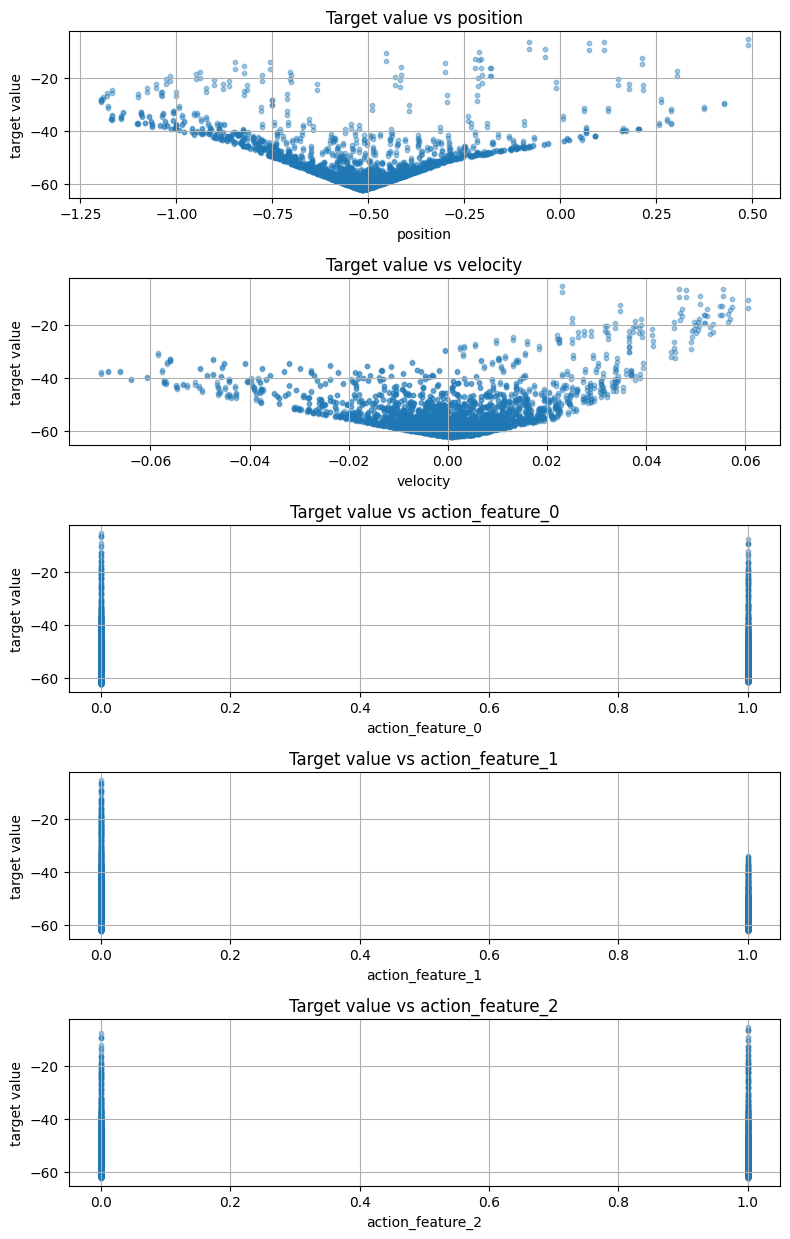

In [91]:
import torch
import matplotlib.pyplot as plt

cases = cases_tensor.detach().cpu()
labels = labels_tensor.detach().cpu().view(-1)

num_features = cases.shape[1]

fig, axes = plt.subplots(
    nrows=num_features,
    ncols=1,
    figsize=(8, 2.5 * num_features),
    sharex=False
)

if num_features == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(cases[:, i], labels, alpha=0.4, s=10)
    feature_name = (
        state_labels[i]
        if i < state_dim
        else f"action_feature_{i - state_dim}"
    )
    ax.set_xlabel(feature_name)
    ax.set_ylabel("target value")
    ax.set_title(f"Target value vs {feature_name}")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [93]:
import numpy as np
import matplotlib.pyplot as plt

regime_weights = False

def plot_y_distribution(y, bin_width=0.1, title="y distribution", show_kde=False):
    """
    Plot a histogram of y with fixed bin width (default 0.1).

    Args:
        y: list | np.ndarray | pd.Series | torch.Tensor
        bin_width: float, width of each bin
        title: str
        show_kde: bool, overlay a simple kernel density (optional)
    """
    # to numpy
    try:
        import torch
        if isinstance(y, torch.Tensor):
            y = y.detach().cpu().numpy()
    except Exception:
        pass
    y = np.asarray(y, dtype=float).ravel()
    y = y[~np.isnan(y)]

    # bins
    y_min, y_max = np.min(y), np.max(y)
    # include the rightmost edge
    bins = np.arange(np.floor(y_min/bin_width)*bin_width,
                    np.ceil(y_max/bin_width)*bin_width + bin_width,
                    bin_width)

    # plot
    plt.figure(figsize=(7,4.5))
    counts, edges, _ = plt.hist(y, bins=bins, edgecolor='black', alpha=0.8)
    plt.xlabel("y")
    plt.ylabel("count")
    plt.title(f"{title} (bin={bin_width})")

    # optional KDE (very light, no seaborn)
    if show_kde:
        from scipy.stats import gaussian_kde
        xs = np.linspace(edges[0], edges[-1], 512)
        kde = gaussian_kde(y, bw_method='scott')
        # scale KDE to histogram counts
        plt.plot(xs, kde(xs) * len(y) * bin_width, linewidth=2)

    plt.tight_layout()
    plt.show()
    return counts, edges

### Configure NN-kNN for regression

In [94]:
cfg = {
    **default_args,
    "task_type": "regression",

    "case_score_mode": "bias_minus_distance",
    # "hard_knn",      # start here (closest to KNN)
    # other options you can try:
    # "bias_minus_distance"
    # "neg_distance_logw"
    # "sigmoid"                (your old style, if you want it back)
    # "hard_knn"               (uniform KNN weights)

    "softmax_over_cases": True,      # model enforces True in regression; kept explicit for clarity
    "tau": 0.3 ,# 1.0,                      # attention sharpness over cases, lower -> sharper
    "case_normalizer": "softmax",  # 'softmax' | 'sparsemax' | 'entmax15'
    # "case_norm_warmup_epochs": 0,       # 50â€“200 is a good sweepï¼Œ 0 if no warm-up
    # "case_norm_warmup_type": "softmax",   # warm-up normalizer

    #for locality regularization in regression
    "regression_locality": False,  # Whether to use locality regularization in regression training
    "lambda_base": 1.0,
    # "lambda_kl": 0.0,        # weight for KL(p||w) attention-to-label proximity (regression only)
    "locality_alpha" : 2.0,    # exponent for distance in locality regularization
    "lambda_expdist": 0.1,   #1.0, weight for expected distance loss (regression only)
    # "lambda_balance": 0.0,    # weight for signed-bias regularizer (regression only)
    # "lambda_cover": 0.0,     #0.5, weight for coverage loss (regression
    # "lambda_pair": 0.0,      #0.5, weight for pos>neg pairwise hinge (regression only)
    # "lambda_ent": 0.0,  # 0.0,      #1e-3, tiny entropy penalty (encourages sparse attention tails)
    # "eps_sigma_multiplier": 0.1, #0.2,0.4 multiplier for sigma_y to define "close" and "far" in pairwise loss
    # "pairwise_margin": 0.05, # required gap: w_pos - w_neg >= margin

    # "locality_warmup_epochs": 0,   # epochs with locality off
    # "locality_ramp_epochs": 0,   # linearly ramp to full strength
    # "locality_schedule": "linear",  # (only linear implemented below)

    # "pre_topk_mask": False,   # enable the pre-normalization K-sparsification, if turned on, this influences nn-cdh to only adapt to top_k neighbors
    # "top_k": 40,         # K for Neighbor Agreement / nDCG in validation and also for explanation mode

    ## NEW
    # "bias_manual_set": True,
    # "bias_manual_value": 0.0,
    # #loss in the main training loop
    # "lambda_case_bias": 1e-3, #1e-3,    # weight for L2 regularization on case bias terms

    # "glocal_fw_set_num": 1, #1
    # "neg_weight_flag": False,        # regression should NOT use negative class weights
    # "sampling_cases_flag": False,    # use all cases for stable regression
    # "case_activation_by_top_k_average": True,  # use percentile-based bias finder
    # "top_k_for_default_case_activation": 20, #mark.
    # "case_activation_default_percentage": 0.1,
    "training_epochs": 7000,
    "batch_size": 64,
    "feature_extractor_lr": 1e-3, #1e-3,1e-4,1e-3,
    "glocal_weightor_lr": 1e-3, #1e-3,5e-4, 1e-3, influence feature weights and glocal weights
    "case_net_lr": 3e-4, #3e-4,1e-4,1e-5,
    "checkpoint_path": "nnknn_regression_best.pth",
    "patience": 80,

    #default feature extractor
    "post_mlp_enabled": False,
    # "post_mlp_dims": (64, 32),
    # "post_mlp_dropout": 0.1,
    # "post_mlp_activation": "relu",

    #Turn them all True or False to turn on/off nn_cdh adaptation
    "nn_cdh_pretrain": False,  # Whether to pretrain nn_cdh adapter
    "use_nn_cdh": False,
    "cdh_aggregate": False,  # "weighted_sum" | "attention"

    "explanation_mode": True
}

# No feature extractor for tabular demo
feature_extractor = None

## Train Model

In [95]:
#already standardized y
# y_mean = y_train.mean()
# y_std = y_train.std().clamp(min=1e-6)
y_train_norm = y_train # (y_train - y_mean) / y_std
y_val_norm   = y_val   # (y_val   - y_mean) / y_std

In [96]:
#train with normalized y
best_acc, glocal_weightor, model = train_model(
    X_train, y_train_norm, X_val, y_val_norm,
    feature_extractor=feature_extractor,
    cfg=cfg
)

print('Best (R^2 proxy in logs).')

cases trainable: False
labels trainable: False
Enforcing softmax_over_cases = True for regression task.
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([1, 5])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([3200])
torch.Size([3200])
torch.Size([3200, 1])
*****************
Training started for training_epochs epochs with batch size 64

[Stage 1] Retrieval-only training for up to 7000 epochs (patience=80)
[Stage1] Epoch 1 - Val R²: 0.9312 | Reg Val Loss: 0.0752
[Stage1] New best (epoch 1) Val Loss: 0.0752 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 2 - Val R²: 0.9385 | Reg Val Loss: 0.0673
[Stage1] New best (epoch 2) Val Loss: 0.0673 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 3 - Val R²: 0.9444 | Reg Val Loss: 0.0608
[Stage1] New best (epoch 3) Val Loss: 0.0608 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 4 - Val R²: 0.9493 | Reg Val Loss: 0.0555
[Stage1] New best (epoch 4) Val Loss: 0

## Evaluate and Visualize

In [97]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

model.eval()
with torch.no_grad():
    preds = []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, *_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.detach().cpu())

    y_pred_z = torch.cat(preds, dim=0).view(-1)
    y_true_z = y_val.view(-1).detach().cpu()

rmse_z = torch.sqrt(F.mse_loss(y_pred_z, y_true_z)).item()
print(f"Validation RMSE (z): {rmse_z:.4f}")

y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

y_pred_raw = y_pred_z * y_std_t + y_mean_t
y_true_raw = y_true_z * y_std_t + y_mean_t
rmse_raw = torch.sqrt(F.mse_loss(y_pred_raw, y_true_raw)).item()
print(f"Validation RMSE (raw): {rmse_raw:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_true_raw.numpy(), y_pred_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation)')
plt.show()

Validation RMSE (z): 0.0502


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

[Z] Pre-adaptation  MSE: 0.002505, RMSE: 0.050048
[Z] Post-adaptation MSE: 0.002505, RMSE: 0.050048
[Z] Î”RMSE (pre - post):  0.000000
[RAW] Pre-adaptation  RMSE: 0.420794
[RAW] Post-adaptation RMSE: 0.420794


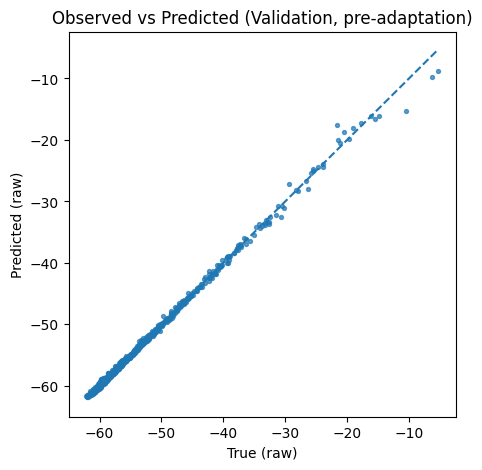

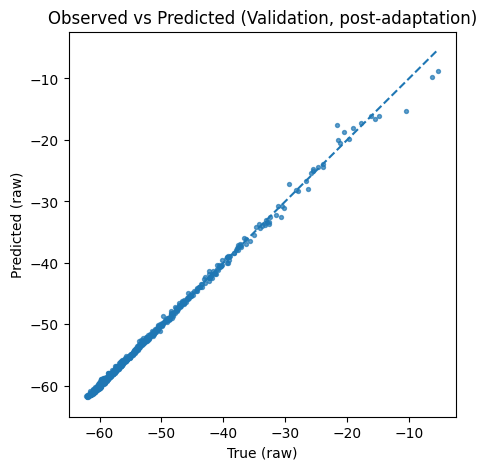

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    pre_preds, post_preds = [], []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, pre_adapt_yhat, *_ = model(X_val[i:i+B].to(device))

        # pre_adapt_yhat may come in different shapes depending on code path
        if pre_adapt_yhat.dim() == 3:
            pre_yhat = pre_adapt_yhat.sum(dim=1).squeeze(-1)  # [B]
        elif pre_adapt_yhat.dim() == 2:
            pre_yhat = pre_adapt_yhat.squeeze(-1)             # [B]
        else:
            pre_yhat = pre_adapt_yhat                         # [B]

        post_preds.append(yhat.detach().cpu().view(-1))
        pre_preds.append(pre_yhat.detach().cpu().view(-1))

    y_pred_post_z = torch.cat(post_preds, dim=0).to(torch.float32)  # z-space
    y_pred_pre_z  = torch.cat(pre_preds,  dim=0).to(torch.float32)  # z-space
    y_true_z      = y_val.detach().cpu().view(-1).to(torch.float32) # z-space

# --- Metrics in z-space (always correct for training/val consistency) ---
mse_pre_z  = F.mse_loss(y_pred_pre_z,  y_true_z).item()
mse_post_z = F.mse_loss(y_pred_post_z, y_true_z).item()
rmse_pre_z  = mse_pre_z ** 0.5
rmse_post_z = mse_post_z ** 0.5

print(f"[Z] Pre-adaptation  MSE: {mse_pre_z:.6f}, RMSE: {rmse_pre_z:.6f}")
print(f"[Z] Post-adaptation MSE: {mse_post_z:.6f}, RMSE: {rmse_post_z:.6f}")
print(f"[Z] Î”RMSE (pre - post):  {rmse_pre_z - rmse_post_z:.6f}")

# --- Optional: convert to raw units if you saved train-split scaler ---
# (RMSE_raw = RMSE_z * y_std_raw)
y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

y_pred_pre_raw  = y_pred_pre_z  * y_std_t + y_mean_t
y_pred_post_raw = y_pred_post_z * y_std_t + y_mean_t
y_true_raw      = y_true_z      * y_std_t + y_mean_t

rmse_pre_raw  = torch.sqrt(F.mse_loss(y_pred_pre_raw,  y_true_raw)).item()
rmse_post_raw = torch.sqrt(F.mse_loss(y_pred_post_raw, y_true_raw)).item()
print(f"[RAW] Pre-adaptation  RMSE: {rmse_pre_raw:.6f}")
print(f"[RAW] Post-adaptation RMSE: {rmse_post_raw:.6f}")

# Plots in raw units (more interpretable)
plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_pre_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_pre_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_pre_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, pre-adaptation)')
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_post_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_post_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_post_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, post-adaptation)')
plt.show()

### Test a single case

In [ ]:
import random
import torch

def test_single_case(model, X_mean, X_std, y_mean, y_std):
    index = random.randint(0, cases_tensor.size(0) - 1)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x_raw = cases_tensor[index].to(device).float()
    x_state  = x_raw[:state_dim]
    x_action = x_raw[state_dim:]
    mean = X_mean.to(device).view(-1)
    std  = X_std.to(device).view(-1)
    x_state_z = (x_state - mean) / std
    x = torch.cat([x_state_z, x_action], dim=0).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        pred_z, *_ = model(x)
    pred_z_val = pred_z.item()
    y_mean_f = float(y_mean)
    y_std_f  = float(y_std)
    pred_raw = pred_z_val * y_std_f + y_mean_f
    print(f"Predicted value (z):   {pred_z_val:.3f}")
    print(f"Predicted value (raw): {pred_raw:.3f}")
    print(f"Expected value: {labels_tensor[index]}")
    print(f"Index: {index}")


In [ ]:
test_single_case(model, X_mean, X_std, y_mean, y_std)

Predicted value (z):   0.062
Predicted value (raw): -52.978
Expected value: -52.98552703857422
Index: 492


In [ ]:
device = next(model.parameters()).device

maxes = []
for i in range(1000):
    x_rand = torch.rand((1, cases_tensor.shape[1]), device=device)
    with torch.no_grad():
        pred, *_ = model(x_rand)
    maxes.append(pred.item())

print(max(maxes))
print(f"Random input prediction: {pred.item():.3f}")


0.10277064889669418
Random input prediction: -0.473


### Evaluate the NN-kNN on MountainCar

In [ ]:
import gymnasium as gym
import torch
import numpy as np

def evaluate_nnknn_mountaincar(model, X_mean, X_std, y_mean=None, y_std=None, episodes=10, render_mode="rgb_array"):
    device = next(model.parameters()).device
    eval_env = gym.make(ENV_ID, render_mode=render_mode)
    model.eval().to(device)

    X_mean = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, state_dim)
    X_std  = torch.as_tensor(X_std,  dtype=torch.float32, device=device).view(1, state_dim).clamp_min(1e-6)

    if y_mean is not None and y_std is not None:
        y_mean = float(torch.as_tensor(y_mean).item())
        y_std  = float(torch.as_tensor(y_std).item())
        use_y_denorm = True
    else:
        use_y_denorm = False

    total_rewards = []

    for ep in range(episodes):
        state, _ = eval_env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, state_dim)
            state_t = (state_t - X_mean) / X_std

            q_values = []
            for action_idx in range(action_dim):
                action_features = encode_action_features_torch([action_idx], device=device).view(1, -1)
                sa_input = torch.cat([state_t, action_features], dim=1)
                with torch.no_grad():
                    out = model(sa_input)

                pred = out[0] if isinstance(out, (tuple, list)) else out
                q_norm = float(pred.view(-1)[0].item())
                q_values.append(q_norm * y_std + y_mean if use_y_denorm else q_norm)

            best_action_idx = int(np.argmax(q_values))
            env_action = action_index_to_env_action(best_action_idx)
            next_state, reward, terminated, truncated, _ = eval_env.step(env_action)
            done = terminated or truncated

            ep_reward += float(reward)
            state = next_state

        total_rewards.append(ep_reward)
        print(f"Episode {ep + 1}/{episodes} | Reward: {ep_reward:.2f}")

    eval_env.close()
    avg_reward = float(np.mean(total_rewards))
    print(f"Average reward over {episodes} episode(s): {avg_reward:.2f}")
    return avg_reward

In [ ]:
avg_reward = evaluate_nnknn_mountaincar(
    model,
    X_mean,
    X_std,
    y_mean=y_mean,
    y_std=y_std,
    episodes=10,
)


Episode 1/10 | Reward: -200.00
Episode 2/10 | Reward: -200.00
Episode 3/10 | Reward: -200.00
Episode 4/10 | Reward: -200.00
Episode 5/10 | Reward: -200.00
Episode 6/10 | Reward: -151.00
Episode 7/10 | Reward: -152.00
Episode 8/10 | Reward: -153.00
Episode 9/10 | Reward: -200.00
Episode 10/10 | Reward: -200.00
Average reward over 10 episode(s): -185.60


### Compare one NN-kNN episode to the DQN baseline

In [ ]:
import gymnasium as gym
import torch
import numpy as np

def evaluate_nnknn_vs_dqn_mountaincar(
    model,
    policy_net,
    X_mean, X_std,
    y_mean=None, y_std=None,
    episodes=1,
    render=False,
    log_every=5,
):
    model_device = next(model.parameters()).device
    dqn_device = next(policy_net.parameters()).device

    eval_env = gym.make(ENV_ID, render_mode="human" if render else None)
    model.eval().to(model_device)
    policy_net.eval().to(dqn_device)

    X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=model_device).view(1, state_dim)
    X_std_t  = torch.as_tensor(X_std,  dtype=torch.float32, device=model_device).view(1, state_dim).clamp_min(1e-6)

    use_y_denorm = (y_mean is not None) and (y_std is not None)
    if use_y_denorm:
        y_mean_f = float(torch.as_tensor(y_mean).view(-1)[0].item())
        y_std_f  = float(torch.as_tensor(y_std).view(-1)[0].item())
    else:
        y_mean_f, y_std_f = 0.0, 1.0

    total_rewards = []

    for ep in range(episodes):
        state, _ = eval_env.reset()
        done = False
        ep_reward = 0.0
        step = 0

        while not done:
            state_raw_model = torch.as_tensor(state, dtype=torch.float32, device=model_device).view(1, state_dim)
            state_std_t = (state_raw_model - X_mean_t) / X_std_t

            nn_q_norm = []
            nn_q_log = []
            for action_idx in range(action_dim):
                action_features = encode_action_features_torch([action_idx], device=model_device).view(1, -1)
                sa_input = torch.cat([state_std_t, action_features], dim=1)
                with torch.no_grad():
                    out = model(sa_input)
                pred = out[0] if isinstance(out, (tuple, list)) else out
                qn = float(pred.view(-1)[0].item())
                nn_q_norm.append(qn)
                nn_q_log.append(qn * y_std_f + y_mean_f if use_y_denorm else qn)

            nn_action = int(np.argmax(nn_q_norm))

            with torch.no_grad():
                state_raw_dqn = torch.as_tensor(state, dtype=torch.float32, device=dqn_device).view(1, state_dim)
                dqn_out = policy_net(state_raw_dqn)
            dqn_q = dqn_out.detach().cpu().view(-1).numpy()
            dqn_action = int(np.argmax(dqn_q))

            if step % log_every == 0:
                print(f"Step {step:03d} | state={np.round(state, 4)}")
                print("  NN-kNN scores:",
                      {action_index_label(i): round(float(nn_q_log[i]), 4) for i in range(action_dim)})
                print("  DQN q-values:",
                      {action_index_label(i): round(float(dqn_q[i]), 4) for i in range(action_dim)})
                print(f"  chosen NN-kNN action: {action_index_label(nn_action)}")
                print(f"  chosen DQN action:    {action_index_label(dqn_action)}")

            env_action = action_index_to_env_action(nn_action)
            next_state, reward, terminated, truncated, _ = eval_env.step(env_action)
            done = terminated or truncated
            ep_reward += float(reward)
            state = next_state
            step += 1

        total_rewards.append(ep_reward)
        print(f"Episode {ep + 1}/{episodes} reward = {ep_reward:.2f}")

    eval_env.close()
    avg = float(np.mean(total_rewards))
    print(f"Average reward: {avg:.2f}")
    return avg

In [ ]:
avg = evaluate_nnknn_vs_dqn_mountaincar(
    model=model,
    policy_net=policy_net,
    X_mean=X_mean, X_std=X_std,
    y_mean=y_mean, y_std=y_std,
    episodes=1,
    log_every=5
)


Step 000 | state=[-0.5313  0.    ]
  NN-kNN scores: {'push left': -61.442, 'coast': -61.442, 'push right': -61.5763}
  DQN q-values: {'push left': -61.5094, 'coast': -61.4566, 'push right': -61.5758}
  chosen NN-kNN action: coast
  chosen DQN action:    coast
Step 005 | state=[-5.304e-01  3.000e-04]
  NN-kNN scores: {'push left': -61.4852, 'coast': -61.4851, 'push right': -61.604}
  DQN q-values: {'push left': -61.5531, 'coast': -61.4989, 'push right': -61.6163}
  chosen NN-kNN action: coast
  chosen DQN action:    coast
Step 010 | state=[-5.283e-01  5.000e-04]
  NN-kNN scores: {'push left': -61.551, 'coast': -61.5509, 'push right': -61.6556}
  DQN q-values: {'push left': -61.6518, 'coast': -61.5969, 'push right': -61.7129}
  chosen NN-kNN action: coast
  chosen DQN action:    coast
Step 015 | state=[-0.5253  0.0006]
  NN-kNN scores: {'push left': -61.6269, 'coast': -61.6269, 'push right': -61.7199}
  DQN q-values: {'push left': -61.7962, 'coast': -61.7415, 'push right': -61.8572}
  ch

In [ ]:
import random
import torch

num = random.randint(0, len(cases) - 1)
example = torch.tensor(cases[num][:state_dim], dtype=torch.float32).unsqueeze(0)

dqn_device = next(policy_net.parameters()).device
nn_device = next(model.parameters()).device

example_dqn = example.to(dqn_device)

with torch.no_grad():
    dqn_q = policy_net(example_dqn)

print("DQN Q-values:", dqn_q.detach().cpu().numpy())

X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=nn_device).view(1, state_dim)
X_std_t  = torch.as_tensor(X_std,  dtype=torch.float32, device=nn_device).view(1, state_dim).clamp_min(1e-6)
state_std = (example.to(nn_device) - X_mean_t) / X_std_t

model.eval()
nn_q_norm = []
for action_idx in range(action_dim):
    action_features = encode_action_features_torch([action_idx], device=nn_device).view(1, -1)
    sa_input = torch.cat([state_std, action_features], dim=1)
    with torch.no_grad():
        out = model(sa_input)
    pred = out[0] if isinstance(out, (tuple, list)) else out
    q_norm = float(pred.view(-1)[0])
    nn_q_norm.append(q_norm)

print("NN-kNN Q_norm:", nn_q_norm)
print("NN-kNN Q_denorm:", [q * float(y_std) + float(y_mean) for q in nn_q_norm])

DQN Q-values: [[-60.31863  -60.299408 -60.483864]]
NN-kNN Q_norm: [-0.7997086644172668, -0.799705982208252, -0.8271398544311523]
NN-kNN Q_denorm: [-60.22695724677226, -60.226934695293494, -60.457593224671655]


C:\Users\merec\AppData\Local\Temp\ipykernel_39840\2675641890.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  example = torch.tensor(cases[num][:state_dim], dtype=torch.float32).unsqueeze(0)


## Watch NN-kNN play MountainCar

### View the top activated MountainCar cases

In [ ]:
# Enable explanation mode
model.top_k_mode = True
k = model.top_k

sample_idx = torch.arange(min(5, X_val.size(0)))

with torch.no_grad():
    final_pred, pred_vals, _, cases, labels, acts = model(X_val[sample_idx].to(device))

# Convert everything back to RAW space
final_pred = final_pred * y_std_t + y_mean_t
labels = labels * y_std_t + y_mean_t
pred_vals = pred_vals * y_std_t + y_mean_t  # <-- important

print("\n The first few cases and their most activated neighbors: ")

for i in range(len(sample_idx)):
    true_val = y_val[sample_idx[i]].item()

    print(f"\nSample {i} (True: {true_val:.4f}, Pred: {final_pred[i].item():.4f}):")
    
    topk_acts, topk_indices = torch.topk(acts[i], k=k)

    print(f"  Sample features: {X_val[sample_idx[i]].cpu().numpy()}")

    accumulated_label = 0.0

    for rank in range(k):
        case_idx = topk_indices[rank].item()
        case_act = topk_acts[rank].item()
        case_feat = cases[i][rank].cpu().numpy()
        case_label = labels[i][rank].item()  # already raw

        print(f"  Neighbor {rank+1}: Index {case_idx}, "
              f"Activation {case_act:.4f}, "
              f"Label (raw) {case_label:.4f}, "
              f"Features {case_feat}")

        accumulated_label += case_label * case_act

    print(f"  Weighted sum of neighbors (raw): {accumulated_label:.4f}")


 The first few cases and their most activated neighbors: 

Sample 0 (True: 1.6849, Pred: -39.0972):
  Sample features: [-1.0755396  1.616524   0.         0.         1.       ]
  Neighbor 1: Index 0, Activation 0.5881, Label (raw) -38.4799, Features [-1.317258   1.5555838  1.         0.         0.       ]
  Neighbor 2: Index 1, Activation 0.2494, Label (raw) -14.0228, Features [-1.6872026  3.0555325  0.         0.         1.       ]
  Neighbor 3: Index 2, Activation 0.1626, Label (raw) -41.4944, Features [-1.1155183  1.3747902  0.         0.         1.       ]
  Weighted sum of neighbors (raw): -32.8715

Sample 1 (True: -0.4611, Pred: -57.1284):
  Sample features: [-0.22938776 -0.9531043   0.          0.          1.        ]
  Neighbor 1: Index 0, Activation 0.7607, Label (raw) -59.8910, Features [-0.1264346 -0.4725333  0.         0.         1.       ]
  Neighbor 2: Index 1, Activation 0.1848, Label (raw) -52.2573, Features [-0.85833466 -0.4595339   0.          0.          1.        ]


In [ ]:
print("y_train raw min/max:", y_train.min().item(), y_train.max().item())
print("y_train raw mean/std:", y_train.mean().item(), y_train.std().item())

print("y_val raw min/max:", y_val.min().item(), y_val.max().item())
print("y_val raw mean/std:", y_val.mean().item(), y_val.std().item())

print("y_mean_t:", y_mean_t.item() if torch.is_tensor(y_mean_t) else y_mean_t)
print("y_std_t:", y_std_t.item() if torch.is_tensor(y_std_t) else y_std_t)

y_train_norm = (y_train - y_mean_t) / y_std_t
y_val_norm = (y_val - y_mean_t) / y_std_t

print("y_train_norm min/max:", y_train_norm.min().item(), y_train_norm.max().item())
print("y_train_norm mean/std:", y_train_norm.mean().item(), y_train_norm.std().item())

print("y_val_norm min/max:", y_val_norm.min().item(), y_val_norm.max().item())
print("y_val_norm mean/std:", y_val_norm.mean().item(), y_val_norm.std().item())

y_train raw min/max: -1.0485212802886963 5.5858473777771
y_train raw mean/std: -4.8190355528277e-07 1.0
y_val raw min/max: -1.0310611724853516 5.739461421966553
y_val raw mean/std: 0.010300734080374241 1.046736240386963
y_mean_t: -53.50316619873047
y_std_t: 8.407800674438477
y_train_norm min/max: 6.23880672454834 7.02787971496582
y_train_norm mean/std: 6.363514423370361 0.11893713474273682
y_val_norm min/max: 6.240883827209473 7.046150207519531
y_val_norm mean/std: 6.364739894866943 0.12449585646390915


In [ ]:
import os
import glob
import gymnasium as gym
import numpy as np
import torch
from gymnasium.wrappers.rendering import RecordVideo
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Video

def _safe_load_font(size=14):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", size=size)
    except Exception:
        return ImageFont.load_default()

def _denorm_state_from_feat(feat_1d, X_mean_state, X_std_state):
    s = np.asarray(feat_1d, dtype=np.float32).reshape(-1)
    state_part = s[:state_dim].copy()
    mean = np.asarray(X_mean_state, dtype=np.float32).reshape(state_dim)
    std = np.asarray(X_std_state, dtype=np.float32).reshape(state_dim)
    std = np.clip(std, 1e-6, None)
    return state_part * std + mean

def _make_topk_mountaincar_panel(
    height, width, step_idx, fps, state_raw, chosen_action, q_values,
    top_cases_feats, top_cases_labels, top_cases_indices, X_mean_state, X_std_state
):
    panel = Image.new("RGB", (width, height), color=(245, 245, 245))
    draw = ImageDraw.Draw(panel)
    font_h = _safe_load_font(15)
    font_s = _safe_load_font(13)
    margin = 14
    t_sec = step_idx / float(fps)

    header = [
        f"NN-kNN MountainCar | env={ENV_VARIANT} | t={t_sec:5.2f}s | step={step_idx}",
        f"Chosen action: {action_index_label(chosen_action)}",
        "   ".join([f"{action_index_label(idx)}={val: .4f}" for idx, val in enumerate(q_values)]),
        f"Current state: position={state_raw[0]: .3f}, velocity={state_raw[1]: .4f}",
        "Top retrieved cases:",
    ]

    y = margin
    for i, line in enumerate(header):
        draw.text((margin, y), line, fill=(20, 20, 20), font=(font_h if i == 0 else font_s))
        y += 18

    for r in range(min(3, len(top_cases_feats))):
        feat = top_cases_feats[r]
        idx = int(top_cases_indices[r]) if top_cases_indices is not None else -1
        lab = float(top_cases_labels[r]) if top_cases_labels is not None else float("nan")
        case_state_raw = _denorm_state_from_feat(feat, X_mean_state, X_std_state)
        action_feat = np.asarray(feat[state_dim:], dtype=np.float32).reshape(-1)

        if is_continuous_action:
            action_desc = f"case throttle={float(action_feat[0]):+.2f}"
        else:
            case_action_idx = int(np.argmax(action_feat))
            action_desc = f"case action={action_index_label(case_action_idx)}"

        line = (
            f"#{r+1} idx={idx} label={lab:.4f} "
            f"pos={case_state_raw[0]: .3f} vel={case_state_raw[1]: .4f} "
            f"{action_desc}"
        )
        draw.text((margin, y), line, fill=(35, 35, 35), font=font_s)
        y += 18

    return np.asarray(panel)

def record_nnknn_mountaincar_with_topk_panel(
    model,
    X_mean,
    X_std,
    y_mean=None,
    y_std=None,
    video_folder="videos_nnknn",
    fps=30,
    max_steps=None,
    seconds_between_updates=0.5,
    k=3,
):
    import imageio.v2 as imageio

    os.makedirs(video_folder, exist_ok=True)

    if max_steps is None:
        max_steps = MAX_STEPS

    model_device = next(model.parameters()).device
    model.eval()
    model.top_k_mode = True
    if hasattr(model, "top_k"):
        model.top_k = k

    env = gym.make(ENV_ID, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: True,
        name_prefix=f"nnknn_{ENV_ID.replace('-', '_')}"
    )

    X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=model_device).view(1, state_dim)
    X_std_t  = torch.as_tensor(X_std, dtype=torch.float32, device=model_device).view(1, state_dim).clamp_min(1e-6)

    X_mean_np = X_mean_t.detach().cpu().numpy().astype(np.float32)
    X_std_np = X_std_t.detach().cpu().numpy().astype(np.float32)

    use_y_denorm = (y_mean is not None) and (y_std is not None)
    if use_y_denorm:
        y_mean_f = float(torch.as_tensor(y_mean).view(-1)[0].item())
        y_std_f  = float(torch.as_tensor(y_std).view(-1)[0].item())
    else:
        y_mean_f, y_std_f = 0.0, 1.0

    state, _ = env.reset()
    panel_every = max(1, int(round(seconds_between_updates * fps)))
    panel_records = []

    for step_idx in range(max_steps):
        state_raw_t = torch.as_tensor(state, dtype=torch.float32, device=model_device).view(1, state_dim)
        state_std_t = (state_raw_t - X_mean_t) / X_std_t

        q_values = []
        per_action_explain = []

        for action_idx in range(action_dim):
            action_features = encode_action_features_torch([action_idx], device=model_device).view(1, -1)
            sa_input = torch.cat([state_std_t, action_features], dim=1)

            with torch.no_grad():
                out = model(sa_input)

            if isinstance(out, (tuple, list)):
                pred = out[0]
                retrieved_cases = out[3] if len(out) > 3 else None
                retrieved_labels = out[4] if len(out) > 4 else None
                activations = out[5] if len(out) > 5 else None
            else:
                pred = out
                retrieved_cases = None
                retrieved_labels = None
                activations = None

            qn = float(pred.view(-1)[0].item())
            q_display = qn * y_std_f + y_mean_f if use_y_denorm else qn
            q_values.append(q_display)
            per_action_explain.append((retrieved_cases, retrieved_labels, activations))

        chosen_action = int(np.argmax(q_values))
        env_action = action_index_to_env_action(chosen_action)
        next_state, reward, terminated, truncated, _ = env.step(env_action)

        if step_idx % panel_every == 0:
            retrieved_cases, retrieved_labels, activations = per_action_explain[chosen_action]

            if activations is not None:
                acts_t = activations[0].detach().cpu().view(-1)
                top_idx = torch.argsort(acts_t, descending=True)[:k].numpy()
            else:
                top_idx = np.empty((0,), dtype=np.int64)

            if retrieved_cases is not None and len(top_idx) > 0:
                rc = retrieved_cases[0] if retrieved_cases.dim() >= 3 else retrieved_cases
                top_cases_feats = rc[top_idx].detach().cpu().numpy().astype(np.float32)
            else:
                top_cases_feats = np.empty((0, state_dim + action_feature_dim), dtype=np.float32)

            if retrieved_labels is not None and len(top_idx) > 0:
                rl = retrieved_labels[0] if retrieved_labels.dim() >= 2 else retrieved_labels
                top_cases_labels = rl[top_idx].detach().cpu().view(-1).numpy().astype(np.float32)
                if use_y_denorm:
                    top_cases_labels = top_cases_labels * y_std_f + y_mean_f
            else:
                top_cases_labels = np.empty((0,), dtype=np.float32)

            panel_img = _make_topk_mountaincar_panel(
                height=220,
                width=1100,
                step_idx=step_idx,
                fps=fps,
                state_raw=np.asarray(state, dtype=np.float32),
                chosen_action=chosen_action,
                q_values=q_values,
                top_cases_feats=top_cases_feats,
                top_cases_labels=top_cases_labels,
                top_cases_indices=top_idx,
                X_mean_state=X_mean_np,
                X_std_state=X_std_np,
            )
            panel_records.append(panel_img)

        state = next_state
        if terminated or truncated:
            break

    env.close()

    mp4_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not mp4_files:
        raise RuntimeError("No NN-kNN video file was created.")

    latest_video = mp4_files[-1]
    print(f"Saved video to: {latest_video}")

    if len(panel_records) > 0:
        panel_path = os.path.join(video_folder, f"topk_panel_{ENV_ID.replace('-', '_')}.gif")
        imageio.mimsave(panel_path, panel_records, fps=max(1, fps // panel_every))
        print(f"Saved top-k panel GIF to: {panel_path}")

    return latest_video


In [ ]:
video_path = record_nnknn_mountaincar_with_topk_panel(
    model=model,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    
    fps=30,
    seconds_between_updates=0.5,
    k=3,
)

print("Saved:", video_path)
Video(video_path, embed=True)


c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


Saved video to: videos_nnknn\nnknn_eval-episode-0.mp4
Saved top-k panel GIF to: videos_nnknn\topk_panel_MountainCar_v0.gif
Saved: videos_nnknn\nnknn_eval-episode-0.mp4


## Comparisons

In [ ]:
def nnknn_q_values_for_state(model, state, X_mean, X_std, y_mean=None, y_std=None, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    state_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, state_dim)
    X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, state_dim)
    X_std_t = torch.as_tensor(X_std, dtype=torch.float32, device=device).view(1, state_dim).clamp_min(1e-6)
    state_z = (state_t - X_mean_t) / X_std_t

    use_y_denorm = (y_mean is not None) and (y_std is not None)
    if use_y_denorm:
        y_mean_f = float(torch.as_tensor(y_mean).view(-1)[0].item())
        y_std_f = float(torch.as_tensor(y_std).view(-1)[0].item())

    q_vals = []
    with torch.no_grad():
        for action_idx in range(action_dim):
            action_features = encode_action_features_torch([action_idx], device=device).view(1, -1)
            sa_input = torch.cat([state_z, action_features], dim=1)
            out = model(sa_input)
            pred = out[0] if isinstance(out, (tuple, list)) else out
            q = float(pred.view(-1)[0].item())
            if use_y_denorm:
                q = q * y_std_f + y_mean_f
            q_vals.append(q)

    return np.asarray(q_vals, dtype=np.float32)


In [ ]:
def dqn_q_values_for_state(policy_net, state, device=None):
    if device is None:
        device = next(policy_net.parameters()).device

    policy_net.eval()
    state_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, state_dim)

    with torch.no_grad():
        q = policy_net(state_t).view(-1).detach().cpu().numpy().astype(np.float32)

    return q


In [ ]:
def collect_policy_report_data(
    model,
    policy_net,
    X_mean,
    X_std,
    y_mean=None,
    y_std=None,
    episodes=10,
    max_steps=None,
):
    if max_steps is None:
        max_steps = MAX_STEPS

    env = gym.make(ENV_ID)
    rows = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        step_idx = 0
        ep_reward = 0.0

        while not done and step_idx < max_steps:
            dqn_q = dqn_q_values_for_state(policy_net, state)
            nn_q = nnknn_q_values_for_state(model, state, X_mean, X_std, y_mean=y_mean, y_std=y_std)

            dqn_action = int(np.argmax(dqn_q))
            nn_action = int(np.argmax(nn_q))

            dqn_sorted = np.sort(dqn_q)
            nn_sorted = np.sort(nn_q)
            dqn_margin = float(dqn_sorted[-1] - dqn_sorted[-2]) if len(dqn_sorted) > 1 else 0.0
            nn_margin = float(nn_sorted[-1] - nn_sorted[-2]) if len(nn_sorted) > 1 else 0.0

            env_action = action_index_to_env_action(nn_action)
            next_state, reward, terminated, truncated, _ = env.step(env_action)
            done = bool(terminated or truncated)

            rows.append({
                "episode": ep,
                "step": step_idx,
                "state": np.asarray(state, dtype=np.float32).copy(),
                "reward": float(reward),
                "dqn_action": dqn_action,
                "nn_action": nn_action,
                "agree": int(dqn_action == nn_action),
                "dqn_q": dqn_q.copy(),
                "nn_q": nn_q.copy(),
                "dqn_margin": dqn_margin,
                "nn_margin": nn_margin,
            })

            ep_reward += float(reward)
            state = next_state
            step_idx += 1

        print(f"Collected episode {ep+1}/{episodes} | NN-kNN reward: {ep_reward:.2f}")

    env.close()
    return rows


In [ ]:
def summarize_policy_report(rows):
    if len(rows) == 0:
        print("No rows collected.")
        return

    n = len(rows)
    agree = sum(r["agree"] for r in rows)
    agreement = agree / n

    dqn_actions = [r["dqn_action"] for r in rows]
    nn_actions = [r["nn_action"] for r in rows]

    print(f"Total compared states: {n}")
    print(f"Action agreement: {agreement:.4f} ({agree}/{n})")

    print("\nDQN action counts:")
    print(Counter(dqn_actions))

    print("\nNN-kNN action counts:")
    print(Counter(nn_actions))

    print("\nConfusion counts (DQN_action, NN_action):")
    conf = Counter((r["dqn_action"], r["nn_action"]) for r in rows)
    for key, val in sorted(conf.items()):
        print(f"{key}: {val}")

    disagree_rows = [r for r in rows if not r["agree"]]
    if disagree_rows:
        mean_dqn_margin_dis = float(np.mean([r["dqn_margin"] for r in disagree_rows]))
        mean_nn_margin_dis = float(np.mean([r["nn_margin"] for r in disagree_rows]))
        print(f"\nMean DQN margin on disagreements: {mean_dqn_margin_dis:.4f}")
        print(f"Mean NN-kNN margin on disagreements: {mean_nn_margin_dis:.4f}")
    else:
        print("\nNo disagreements found.")


In [ ]:
def show_biggest_disagreements(rows, top_n=10):
    disagree_rows = [r for r in rows if not r["agree"]]
    if not disagree_rows:
        print("No disagreements found.")
        return

    scored = []
    for r in disagree_rows:
        gap = float(np.max(np.abs(r["dqn_q"] - r["nn_q"])))
        scored.append((gap, r))

    scored.sort(key=lambda x: x[0], reverse=True)

    for i, (gap, r) in enumerate(scored[:top_n], start=1):
        print(f"\n#{i}")
        print(f"Episode {r['episode']} Step {r['step']}")
        print(f"State: {r['state']}")
        print(f"DQN Q: {r['dqn_q']} -> action {r['dqn_action']} ({action_index_label(r['dqn_action'])})")
        print(f"NN  Q: {r['nn_q']} -> action {r['nn_action']} ({action_index_label(r['nn_action'])})")
        print(f"DQN margin: {r['dqn_margin']:.4f}")
        print(f"NN  margin: {r['nn_margin']:.4f}")
        print(f"Max abs Q diff: {gap:.4f}")



In [ ]:
def evaluate_policy_rewards_separately(model, policy_net, X_mean, X_std, y_mean=None, y_std=None, episodes=10, max_steps=None):
    if max_steps is None:
        max_steps = MAX_STEPS

    def run_actor(actor_name):
        env = gym.make(ENV_ID)
        rewards = []

        for ep in range(episodes):
            state, _ = env.reset()
            done = False
            total_reward = 0.0
            step_idx = 0

            while not done and step_idx < max_steps:
                if actor_name == "dqn":
                    q = dqn_q_values_for_state(policy_net, state)
                    action_idx = int(np.argmax(q))
                else:
                    q = nnknn_q_values_for_state(model, state, X_mean, X_std, y_mean=y_mean, y_std=y_std)
                    action_idx = int(np.argmax(q))

                env_action = action_index_to_env_action(action_idx)
                next_state, reward, terminated, truncated, _ = env.step(env_action)
                done = bool(terminated or truncated)

                total_reward += float(reward)
                state = next_state
                step_idx += 1

            rewards.append(total_reward)
            print(f"{actor_name.upper()} episode {ep+1}/{episodes}: reward={total_reward:.2f}")

        env.close()
        return rewards

    dqn_rewards = run_actor("dqn")
    nn_rewards = run_actor("nn")

    print("\nSummary")
    print(f"DQN mean reward:    {np.mean(dqn_rewards):.2f}")
    print(f"NN-kNN mean reward: {np.mean(nn_rewards):.2f}")

    return dqn_rewards, nn_rewards


In [ ]:
dqn_rewards, nn_rewards = evaluate_policy_rewards_separately(
    model=model,
    policy_net=policy_net,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    episodes=10,
)


DQN episode 1/10: reward=-200.00
DQN episode 2/10: reward=-200.00
DQN episode 3/10: reward=-200.00
DQN episode 4/10: reward=-154.00
DQN episode 5/10: reward=-200.00
DQN episode 6/10: reward=-200.00
DQN episode 7/10: reward=-200.00
DQN episode 8/10: reward=-200.00
DQN episode 9/10: reward=-200.00
DQN episode 10/10: reward=-200.00
NN episode 1/10: reward=-200.00
NN episode 2/10: reward=-200.00
NN episode 3/10: reward=-121.00
NN episode 4/10: reward=-200.00
NN episode 5/10: reward=-200.00
NN episode 6/10: reward=-142.00
NN episode 7/10: reward=-200.00
NN episode 8/10: reward=-200.00
NN episode 9/10: reward=-150.00
NN episode 10/10: reward=-167.00

Summary
DQN mean reward:    -195.40
NN-kNN mean reward: -178.00


In [ ]:
from collections import Counter
report_rows = collect_policy_report_data(
    model=model,
    policy_net=policy_net,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    episodes=10,
)

summarize_policy_report(report_rows)


Collected episode 1/10 | NN-kNN reward: -200.00
Collected episode 2/10 | NN-kNN reward: -200.00
Collected episode 3/10 | NN-kNN reward: -176.00
Collected episode 4/10 | NN-kNN reward: -135.00
Collected episode 5/10 | NN-kNN reward: -147.00
Collected episode 6/10 | NN-kNN reward: -200.00
Collected episode 7/10 | NN-kNN reward: -200.00
Collected episode 8/10 | NN-kNN reward: -200.00
Collected episode 9/10 | NN-kNN reward: -200.00
Collected episode 10/10 | NN-kNN reward: -123.00
Total compared states: 1781
Action agreement: 0.7238 (1289/1781)

DQN action counts:
Counter({1: 1171, 2: 444, 0: 166})

NN-kNN action counts:
Counter({1: 894, 2: 694, 0: 193})

Confusion counts (DQN_action, NN_action):
(0, 0): 56
(0, 1): 86
(0, 2): 24
(1, 0): 120
(1, 1): 807
(1, 2): 244
(2, 0): 17
(2, 1): 1
(2, 2): 426

Mean DQN margin on disagreements: 0.0693
Mean NN-kNN margin on disagreements: 0.1327


In [ ]:
show_biggest_disagreements(report_rows, top_n=10)




#1
Episode 9 Step 121
State: [0.47264656 0.01753976]
DQN Q: [-12.808138  -11.8900795 -10.937504 ] -> action 2 (push right)
NN  Q: [-11.125445 -11.125445 -11.145608] -> action 0 (push left)
DQN margin: 0.9526
NN  margin: 0.0000
Max abs Q diff: 1.6827

#2
Episode 3 Step 132
State: [0.4659779  0.01807702]
DQN Q: [-12.844423  -11.9184265 -10.957595 ] -> action 2 (push right)
NN  Q: [-11.18705  -11.187035 -11.236539] -> action 1 (coast)
DQN margin: 0.9608
NN  margin: 0.0000
Max abs Q diff: 1.6574

#3
Episode 9 Step 120
State: [0.4551068  0.01904984]
DQN Q: [-12.811899 -11.869438 -10.891316] -> action 2 (push right)
NN  Q: [-11.270969 -11.270969 -11.333043] -> action 0 (push left)
DQN margin: 0.9781
NN  margin: 0.0000
Max abs Q diff: 1.5409

#4
Episode 3 Step 133
State: [0.4836249  0.01764701]
DQN Q: [-11.81098  -10.869943  -9.891796] -> action 2 (push right)
NN  Q: [-10.465688 -10.465688 -10.554554] -> action 0 (push left)
DQN margin: 0.9781
NN  margin: 0.0000
Max abs Q diff: 1.3453

#5
Ep